# Bamboo Passage human-QC inter-rater reliability

**Purpose.** This notebook evaluates agreement among Abbas, Liya, Samaana, and Samara at three prespecified levels:

1. **Family presence:** a family is present when a rater marks at least one source/item in that family anywhere in the recording.
2. **Specific source/item presence:** an item is present when it has at least one valid annotated interval anywhere in the recording.
3. **Temporal alignment:** intervals for the same recording and same family/item are matched one-to-one. The primary temporal criterion requires both onset and offset to differ by no more than the configured tolerance (default: ±1.0 s).

The primary analysis uses the **six signal-quality families**: Environmental noise, Volume unstable, Clipping, Reverberation/echo, Platform effects, and Temporal discontinuities. `Any non-task related content` and `Competing speech` are retained as optional ancillary families.

**Statistical design.** Presence agreement is calculated across recordings rated by all four RAs. The notebook reports observed pairwise agreement, positive and negative agreement, Fleiss' kappa, Gwet's AC1, unanimous agreement, pairwise Cohen's kappa, and rater-specific detection rates. Gwet's AC1 is emphasized because rare labels can make kappa unstable despite high observed agreement. Temporal agreement is summarized pairwise across the six rater pairs.

In [1]:
# Cell 1 — Configuration
from pathlib import Path
import os

ROOT = Path(os.environ.get(
    "BAMBOO_RELIABILITY_ROOT",
    r"C:\Users\musikicn\Desktop\QC\Segmentation\Reliability",
))

RATERS = ["Abbas", "Liya", "Samaana", "Samara"]

PRIMARY_FAMILIES = [
    "Environmental noise",
    "Volume unstable",
    "Clipping",
    "Reverberation/echo",
    "Platform effects",
    "Temporal discontinuities",
]
ANCILLARY_FAMILIES = ["Any non-task related content", "Competing speech"]
INCLUDE_ANCILLARY_IN_PRIMARY = False
ANALYSIS_FAMILIES = PRIMARY_FAMILIES + (ANCILLARY_FAMILIES if INCLUDE_ANCILLARY_IN_PRIMARY else [])

TIME_TOLERANCE_SEC = 1.0
MERGE_TOUCHING_GAP_SEC = 1e-6
BOOTSTRAP_ITERATIONS = 2000
RANDOM_SEED = 20260730
STRICT_DUPLICATE_RECORDINGS = True

OUTPUT_DIR = ROOT / "_reliability_analysis_outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input root:  {ROOT}")
print(f"Output root: {OUTPUT_DIR}")
print(f"Primary families ({len(ANALYSIS_FAMILIES)}): {ANALYSIS_FAMILIES}")
print(f"Temporal tolerance: ±{TIME_TOLERANCE_SEC:.3f} s")

Input root:  C:\Users\musikicn\Desktop\QC\Segmentation\Reliability
Output root: C:\Users\musikicn\Desktop\QC\Segmentation\Reliability\_reliability_analysis_outputs
Primary families (6): ['Environmental noise', 'Volume unstable', 'Clipping', 'Reverberation/echo', 'Platform effects', 'Temporal discontinuities']
Temporal tolerance: ±1.000 s


In [2]:
# Cell 2 — Imports and display settings
import ast
import hashlib
import itertools
import json
import math
import re
import warnings
from collections import defaultdict
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)

EPS = 1e-12

## 1. Discover and validate annotation files

The recording key is taken from the internal `file_name` column whenever possible. This avoids mismatches caused by severity prefixes or copy suffixes such as `(1)` in exported CSV filenames. Duplicate exports for the same rater and recording are treated as a blocking data-integrity issue by default.

In [3]:
# Cell 3 — File discovery and canonical recording IDs
REQUIRED_BASE_COLUMNS = {
    "file_name",
    "onset_seconds_absolute",
    "offset_seconds_absolute",
}


def normalise_recording_id(value: str) -> str:
    text = str(value).strip().replace("\\", "/")
    name = text.rsplit("/", 1)[-1]
    stem = re.sub(r"\.(wav|webm|mp3|m4a|flac|csv)$", "", name, flags=re.IGNORECASE)
    stem = re.sub(r"_segments(?:\s*\(\d+\))?$", "", stem, flags=re.IGNORECASE)
    return stem.strip().lower()


def read_recording_id(csv_path: Path) -> tuple[str, str]:
    preview = pd.read_csv(csv_path, nrows=3)
    missing = REQUIRED_BASE_COLUMNS - set(preview.columns)
    if missing:
        raise ValueError(f"{csv_path}: missing required columns {sorted(missing)}")
    nonempty = preview["file_name"].dropna().astype(str).str.strip()
    raw = nonempty.iloc[0] if not nonempty.empty else csv_path.stem
    return normalise_recording_id(raw), raw


discovery_rows = []
for rater in RATERS:
    folder = ROOT / rater
    if not folder.exists():
        raise FileNotFoundError(f"Missing rater folder: {folder}")
    paths = sorted(p for p in folder.rglob("*.csv") if OUTPUT_DIR not in p.parents)
    for path in paths:
        recording_id, internal_name = read_recording_id(path)
        discovery_rows.append({
            "rater": rater,
            "recording_id": recording_id,
            "internal_file_name": internal_name,
            "csv_path": str(path),
            "csv_name": path.name,
            "size_bytes": path.stat().st_size,
            "modified_time": datetime.fromtimestamp(path.stat().st_mtime).isoformat(timespec="seconds"),
        })

file_inventory = pd.DataFrame(discovery_rows)
if file_inventory.empty:
    raise RuntimeError(f"No annotation CSVs found under {ROOT}")

duplicates = (
    file_inventory.groupby(["rater", "recording_id"], as_index=False)
    .size()
    .query("size > 1")
)
file_inventory.to_csv(OUTPUT_DIR / "01_file_inventory.csv", index=False)
duplicates.to_csv(OUTPUT_DIR / "01_duplicate_recordings.csv", index=False)

print(file_inventory.groupby("rater").agg(csv_files=("csv_path", "size"), unique_recordings=("recording_id", "nunique")))
if not duplicates.empty:
    display(duplicates.head(20))
    if STRICT_DUPLICATE_RECORDINGS:
        raise RuntimeError(
            "Duplicate rater/recording exports were found. Resolve them or set "
            "STRICT_DUPLICATE_RECORDINGS=False after adjudicating which copy is authoritative."
        )

         csv_files  unique_recordings
rater                                
Abbas           70                 70
Liya            69                 69
Samaana         70                 70
Samara          70                 70


In [4]:
# Cell 4 — Coverage and common-recording universe
coverage = (
    file_inventory.assign(available=1)
    .pivot_table(index="recording_id", columns="rater", values="available", aggfunc="max", fill_value=0)
    .reindex(columns=RATERS, fill_value=0)
    .astype(int)
)
coverage["n_raters"] = coverage[RATERS].sum(axis=1)
coverage["rated_by_all_four"] = coverage["n_raters"].eq(len(RATERS))
coverage.reset_index().to_csv(OUTPUT_DIR / "02_recording_coverage.csv", index=False)

COMMON_RECORDINGS = coverage.index[coverage["rated_by_all_four"]].tolist()
if not COMMON_RECORDINGS:
    raise RuntimeError("No recording was rated by all configured raters.")

pairwise_coverage_rows = []
for a, b in itertools.combinations(RATERS, 2):
    n = int(((coverage[a] == 1) & (coverage[b] == 1)).sum())
    pairwise_coverage_rows.append({"rater_a": a, "rater_b": b, "common_recordings": n})
pairwise_coverage = pd.DataFrame(pairwise_coverage_rows)
pairwise_coverage.to_csv(OUTPUT_DIR / "02_pairwise_coverage.csv", index=False)

print(f"Recordings rated by all four RAs: {len(COMMON_RECORDINGS)}")
display(pairwise_coverage)

Recordings rated by all four RAs: 69


,rater_a,rater_b,common_recordings
0,Abbas,Liya,69
1,Abbas,Samaana,70
2,Abbas,Samara,70
3,Liya,Samaana,69
4,Liya,Samara,69
5,Samaana,Samara,70


## 2. Parse annotation dictionaries and reconstruct continuous events

Each family cell is a JSON-like dictionary mapping a source/item to a list of `[onset, offset]` intervals. Valid intervals are pooled across the GUI's fixed rows and merged when they overlap or touch. This is essential for continuous artifacts that were exported as adjacent 5-second pieces.

In [5]:
# Cell 5 — Robust parser and interval validation

def parse_mapping_cell(value, context: str) -> dict:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return {}
    if isinstance(value, dict):
        obj = value
    else:
        text = str(value).strip()
        if not text or text.lower() in {"nan", "none", "null"}:
            return {}
        try:
            obj = json.loads(text)
        except json.JSONDecodeError:
            try:
                obj = ast.literal_eval(text)
            except Exception as exc:
                raise ValueError(f"Cannot parse annotation dictionary at {context}: {text[:200]}") from exc
    if not isinstance(obj, dict):
        raise ValueError(f"Expected a dictionary at {context}, received {type(obj).__name__}")
    return obj


def validated_intervals(raw_intervals, context: str) -> list[tuple[float, float]]:
    if raw_intervals in (None, "", []):
        return []
    if not isinstance(raw_intervals, (list, tuple)):
        raise ValueError(f"Intervals must be a list at {context}: {raw_intervals!r}")
    out = []
    for interval in raw_intervals:
        if not isinstance(interval, (list, tuple)) or len(interval) != 2:
            raise ValueError(f"Invalid interval at {context}: {interval!r}")
        onset, offset = float(interval[0]), float(interval[1])
        if not (np.isfinite(onset) and np.isfinite(offset)):
            raise ValueError(f"Non-finite interval at {context}: {interval!r}")
        if onset < 0 or offset < onset:
            raise ValueError(f"Invalid interval bounds at {context}: {interval!r}")
        if offset - onset <= EPS:
            warnings.warn(f"Zero-duration interval ignored at {context}: {interval!r}")
            continue
        out.append((onset, offset))
    return out


def merge_intervals(intervals, gap: float = MERGE_TOUCHING_GAP_SEC) -> list[tuple[float, float]]:
    if not intervals:
        return []
    ordered = sorted((float(a), float(b)) for a, b in intervals)
    merged = [list(ordered[0])]
    for onset, offset in ordered[1:]:
        if onset <= merged[-1][1] + gap:
            merged[-1][1] = max(merged[-1][1], offset)
        else:
            merged.append([onset, offset])
    return [(a, b) for a, b in merged]

In [6]:
# Cell 6 — Build schema and event ledger
schema_items = defaultdict(set)
raw_event_rows = []
source_file_rows = []

for row in file_inventory.itertuples(index=False):
    df = pd.read_csv(row.csv_path)
    family_columns = [c for c in df.columns if c not in {
        "file_name", "source_path", "segment_number", "segment_type", "pause_position",
        "onset_seconds_absolute", "offset_seconds_absolute", "duration_seconds"
    }]
    unknown_primary = [f for f in ANALYSIS_FAMILIES if f not in family_columns]
    if unknown_primary:
        raise ValueError(f"{row.csv_path}: missing configured families {unknown_primary}")

    source_file_rows.append({
        "rater": row.rater,
        "recording_id": row.recording_id,
        "csv_path": row.csv_path,
        "n_gui_rows": len(df),
        "recording_start_sec": pd.to_numeric(df["onset_seconds_absolute"], errors="coerce").min(),
        "recording_end_sec": pd.to_numeric(df["offset_seconds_absolute"], errors="coerce").max(),
    })

    for row_idx, ann_row in df.iterrows():
        for family in family_columns:
            mapping = parse_mapping_cell(
                ann_row[family],
                context=f"{row.csv_name}, row {row_idx + 2}, family {family}",
            )
            for item, raw_intervals in mapping.items():
                item = str(item).strip()
                schema_items[family].add(item)
                intervals = validated_intervals(
                    raw_intervals,
                    context=f"{row.csv_name}, row {row_idx + 2}, family {family}, item {item}",
                )
                for onset, offset in intervals:
                    raw_event_rows.append({
                        "rater": row.rater,
                        "recording_id": row.recording_id,
                        "family": family,
                        "item": item,
                        "onset_sec": onset,
                        "offset_sec": offset,
                        "duration_sec": offset - onset,
                        "csv_path": row.csv_path,
                        "gui_row": row_idx + 2,
                    })

schema_df = pd.DataFrame([
    {"family": family, "item": item, "included_in_primary": family in ANALYSIS_FAMILIES}
    for family in sorted(schema_items)
    for item in sorted(schema_items[family])
])
schema_df.to_csv(OUTPUT_DIR / "03_annotation_schema.csv", index=False)

raw_events = pd.DataFrame(raw_event_rows)
raw_events.to_csv(OUTPUT_DIR / "04_raw_event_ledger.csv", index=False)

merged_rows = []
if not raw_events.empty:
    for keys, group in raw_events.groupby(["rater", "recording_id", "family", "item"], sort=True):
        intervals = merge_intervals(group[["onset_sec", "offset_sec"]].itertuples(index=False, name=None))
        for event_number, (onset, offset) in enumerate(intervals, start=1):
            merged_rows.append({
                "rater": keys[0], "recording_id": keys[1], "family": keys[2], "item": keys[3],
                "event_number": event_number, "onset_sec": onset, "offset_sec": offset,
                "duration_sec": offset - onset,
            })
merged_events = pd.DataFrame(merged_rows, columns=[
    "rater", "recording_id", "family", "item", "event_number", "onset_sec", "offset_sec", "duration_sec"
])
merged_events.to_csv(OUTPUT_DIR / "05_merged_event_ledger.csv", index=False)
pd.DataFrame(source_file_rows).to_csv(OUTPUT_DIR / "05_source_file_summary.csv", index=False)

print(f"Schema families: {len(schema_items)}")
print(f"Schema items:    {sum(len(v) for v in schema_items.values())}")
print(f"Raw intervals:   {len(raw_events)}")
print(f"Merged events:   {len(merged_events)}")
display(schema_df.groupby("family").agg(items=("item", "nunique"), primary=("included_in_primary", "max")))

Schema families: 8
Schema items:    28
Raw intervals:   6559
Merged events:   2398


,items,primary
family,,
Any non-task related content,6,False
Clipping,3,True
Competing speech,2,False
Environmental noise,7,True
Platform effects,2,True
Reverberation/echo,2,True
Temporal discontinuities,3,True
Volume unstable,3,True


## 3. Recording-level family and source/item presence

All four raters are evaluated on exactly the same recording universe. A zero means that the source/family was not marked anywhere in the recording; a one means at least one valid interval was marked.

In [7]:
# Cell 7 — Complete binary presence ledgers
primary_schema = schema_df[schema_df["family"].isin(ANALYSIS_FAMILIES)].copy()
if primary_schema.empty:
    raise RuntimeError("No items were found for the configured primary families.")

item_index = pd.MultiIndex.from_frame(
    pd.MultiIndex.from_product(
        [COMMON_RECORDINGS, ANALYSIS_FAMILIES, RATERS],
        names=["recording_id", "family", "rater"],
    ).to_frame(index=False)
    .merge(primary_schema[["family", "item"]], on="family", how="left")
    [["recording_id", "family", "item", "rater"]]
)

item_presence = pd.DataFrame(index=item_index).reset_index()
item_presence["present"] = 0
if not merged_events.empty:
    detected = (
        merged_events[
            merged_events["recording_id"].isin(COMMON_RECORDINGS)
            & merged_events["family"].isin(ANALYSIS_FAMILIES)
        ][["recording_id", "family", "item", "rater"]]
        .drop_duplicates()
        .assign(present=1)
    )
    item_presence = item_presence.drop(columns="present").merge(
        detected, on=["recording_id", "family", "item", "rater"], how="left"
    )
    item_presence["present"] = item_presence["present"].fillna(0).astype(int)

family_presence = (
    item_presence.groupby(["recording_id", "family", "rater"], as_index=False)["present"]
    .max()
)

item_presence.to_csv(OUTPUT_DIR / "06_item_presence_long.csv", index=False)
family_presence.to_csv(OUTPUT_DIR / "06_family_presence_long.csv", index=False)

print(f"Family units: {family_presence[['recording_id','family']].drop_duplicates().shape[0]}")
print(f"Item units:   {item_presence[['recording_id','family','item']].drop_duplicates().shape[0]}")

Family units: 414
Item units:   1380


In [8]:
# Cell 8 — Reliability functions

def safe_div(num, den):
    return np.nan if den == 0 else num / den


def pooled_binary_counts(matrix: pd.DataFrame) -> dict:
    a = b = c = d = 0
    for ra, rb in itertools.combinations(matrix.columns, 2):
        x = matrix[ra].to_numpy(dtype=int)
        y = matrix[rb].to_numpy(dtype=int)
        a += int(((x == 1) & (y == 1)).sum())
        b += int(((x == 1) & (y == 0)).sum())
        c += int(((x == 0) & (y == 1)).sum())
        d += int(((x == 0) & (y == 0)).sum())
    return {"both_positive": a, "a_only": b, "b_only": c, "both_negative": d}


def multi_rater_binary_metrics(matrix: pd.DataFrame) -> dict:
    arr = matrix.to_numpy(dtype=float)
    n_units, n_raters = arr.shape
    if n_units == 0 or n_raters < 2 or np.isnan(arr).any():
        raise ValueError("Reliability matrix must be complete and contain at least two raters.")
    positives = arr.sum(axis=1)
    unit_agreement = (
        positives * (positives - 1) + (n_raters - positives) * (n_raters - positives - 1)
    ) / (n_raters * (n_raters - 1))
    observed = float(unit_agreement.mean())
    prevalence = float(arr.mean())
    fleiss_expected = prevalence**2 + (1 - prevalence)**2
    fleiss_kappa = safe_div(observed - fleiss_expected, 1 - fleiss_expected)
    ac1_expected = 2 * prevalence * (1 - prevalence)
    gwet_ac1 = safe_div(observed - ac1_expected, 1 - ac1_expected)
    counts = pooled_binary_counts(matrix)
    a, b, c, d = counts["both_positive"], counts["a_only"], counts["b_only"], counts["both_negative"]
    return {
        "units": int(n_units),
        "raters": int(n_raters),
        "positive_prevalence": prevalence,
        "observed_pairwise_agreement": observed,
        "positive_agreement": safe_div(2 * a, 2 * a + b + c),
        "negative_agreement": safe_div(2 * d, 2 * d + b + c),
        "unanimous_agreement": float(((positives == 0) | (positives == n_raters)).mean()),
        "unanimous_positive": float((positives == n_raters).mean()),
        "fleiss_kappa": fleiss_kappa,
        "gwet_ac1": gwet_ac1,
        **counts,
    }


def cohen_pair_metrics(x: pd.Series, y: pd.Series) -> dict:
    x = x.to_numpy(dtype=int)
    y = y.to_numpy(dtype=int)
    a = int(((x == 1) & (y == 1)).sum())
    b = int(((x == 1) & (y == 0)).sum())
    c = int(((x == 0) & (y == 1)).sum())
    d = int(((x == 0) & (y == 0)).sum())
    n = len(x)
    observed = safe_div(a + d, n)
    p_x = safe_div(a + b, n)
    p_y = safe_div(a + c, n)
    expected = p_x * p_y + (1 - p_x) * (1 - p_y)
    kappa = safe_div(observed - expected, 1 - expected)
    return {
        "comparisons": n, "both_detected": a, "both_absent": d,
        "rater_a_only": b, "rater_b_only": c,
        "rater_a_detection_rate": p_x, "rater_b_detection_rate": p_y,
        "overall_agreement": observed,
        "positive_agreement": safe_div(2 * a, 2 * a + b + c),
        "negative_agreement": safe_div(2 * d, 2 * d + b + c),
        "cohens_kappa": kappa,
    }


def pivot_presence(long_df: pd.DataFrame, unit_cols: list[str]) -> pd.DataFrame:
    matrix = long_df.pivot_table(index=unit_cols, columns="rater", values="present", aggfunc="max")
    matrix = matrix.reindex(columns=RATERS)
    if matrix.isna().any().any():
        raise RuntimeError("Incomplete presence matrix after restricting to common recordings.")
    return matrix.astype(int)


def bootstrap_overall(long_df: pd.DataFrame, unit_cols: list[str], iterations: int = BOOTSTRAP_ITERATIONS):
    rng = np.random.default_rng(RANDOM_SEED)
    recording_ids = np.array(sorted(long_df["recording_id"].unique()))
    estimates = []
    for _ in range(iterations):
        sampled = rng.choice(recording_ids, size=len(recording_ids), replace=True)
        pieces = []
        for draw, recording_id in enumerate(sampled):
            part = long_df[long_df["recording_id"] == recording_id].copy()
            part["bootstrap_recording_id"] = f"{recording_id}__draw{draw}"
            pieces.append(part)
        boot = pd.concat(pieces, ignore_index=True)
        boot_units = ["bootstrap_recording_id"] + [c for c in unit_cols if c != "recording_id"]
        metrics = multi_rater_binary_metrics(pivot_presence(boot, boot_units))
        estimates.append({k: metrics[k] for k in [
            "observed_pairwise_agreement", "positive_agreement", "negative_agreement",
            "fleiss_kappa", "gwet_ac1"
        ]})
    est = pd.DataFrame(estimates)
    return {
        f"{col}_ci_low": float(est[col].quantile(0.025))
        for col in est.columns
    } | {
        f"{col}_ci_high": float(est[col].quantile(0.975))
        for col in est.columns
    }

In [9]:
# Cell 9 — Overall, family-specific, item-specific, and pairwise presence agreement
family_matrix = pivot_presence(family_presence, ["recording_id", "family"])
item_matrix = pivot_presence(item_presence, ["recording_id", "family", "item"])

overall_rows = []
for level, long_df, matrix, unit_cols in [
    ("family presence", family_presence, family_matrix, ["recording_id", "family"]),
    ("specific item presence", item_presence, item_matrix, ["recording_id", "family", "item"]),
]:
    result = {"analysis_level": level, **multi_rater_binary_metrics(matrix)}
    result.update(bootstrap_overall(long_df, unit_cols))
    overall_rows.append(result)
overall_reliability = pd.DataFrame(overall_rows)

family_rows = []
for family, group in family_presence.groupby("family", sort=True):
    matrix = pivot_presence(group, ["recording_id", "family"])
    family_rows.append({"family": family, **multi_rater_binary_metrics(matrix)})
family_reliability = pd.DataFrame(family_rows)

item_rows = []
for (family, item), group in item_presence.groupby(["family", "item"], sort=True):
    matrix = pivot_presence(group, ["recording_id", "family", "item"])
    item_rows.append({"family": family, "item": item, **multi_rater_binary_metrics(matrix)})
item_reliability = pd.DataFrame(item_rows)

pairwise_rows = []
for level, matrix in [("family presence", family_matrix), ("specific item presence", item_matrix)]:
    for a, b in itertools.combinations(RATERS, 2):
        pairwise_rows.append({
            "analysis_level": level, "rater_a": a, "rater_b": b,
            **cohen_pair_metrics(matrix[a], matrix[b]),
        })
pairwise_reliability = pd.DataFrame(pairwise_rows)

rater_detection_rates = pd.concat([
    family_presence.groupby(["family", "rater"], as_index=False)["present"].mean().assign(level="family"),
    item_presence.groupby(["family", "item", "rater"], as_index=False)["present"].mean().assign(level="item"),
], ignore_index=True, sort=False)

overall_reliability.to_csv(OUTPUT_DIR / "07_overall_presence_reliability.csv", index=False)
family_reliability.to_csv(OUTPUT_DIR / "08_family_reliability.csv", index=False)
item_reliability.to_csv(OUTPUT_DIR / "09_item_reliability.csv", index=False)
pairwise_reliability.to_csv(OUTPUT_DIR / "10_pairwise_presence_reliability.csv", index=False)
rater_detection_rates.to_csv(OUTPUT_DIR / "11_rater_detection_rates.csv", index=False)

display(overall_reliability)
display(family_reliability.sort_values("gwet_ac1"))

,analysis_level,units,raters,positive_prevalence,observed_pairwise_agreement,positive_agreement,negative_agreement,unanimous_agreement,unanimous_positive,fleiss_kappa,gwet_ac1,both_positive,a_only,b_only,both_negative,observed_pairwise_agreement_ci_low,positive_agreement_ci_low,negative_agreement_ci_low,fleiss_kappa_ci_low,gwet_ac1_ci_low,observed_pairwise_agreement_ci_high,positive_agreement_ci_high,negative_agreement_ci_high,fleiss_kappa_ci_high,gwet_ac1_ci_high
0,family presence,414,4,0.261473,0.780596,0.580446,0.851458,0.594203,0.108696,0.431905,0.642542,377,239,306,1562,0.752013,0.532342,0.829196,0.366841,0.588222,0.807971,0.624341,0.871964,0.490010,0.693322
1,specific item presence,1380,4,0.099094,0.900362,0.497258,0.944701,0.812319,0.030435,0.441959,0.878705,408,374,451,7047,0.888644,0.443621,0.937786,0.383221,0.862585,0.912440,0.546126,0.951715,0.495502,0.894801


,family,units,raters,positive_prevalence,observed_pairwise_agreement,positive_agreement,negative_agreement,unanimous_agreement,unanimous_positive,fleiss_kappa,gwet_ac1,both_positive,a_only,b_only,both_negative
0,Clipping,69,4,0.217391,0.657005,0.211111,0.780864,0.362319,0.000000,-0.008025,0.480102,19,70,72,253
3,Reverberation/echo,69,4,0.235507,0.736715,0.441026,0.827804,0.521739,0.057971,0.268830,0.588561,43,46,63,262
5,Volume unstable,69,4,0.181159,0.739130,0.280000,0.840708,0.507246,0.014493,0.120708,0.629088,21,56,52,285
2,Platform effects,69,4,0.137681,0.787440,0.228070,0.876751,0.608696,0.000000,0.104821,0.721251,13,32,56,313
1,Environmental noise,69,4,0.764493,0.823671,0.884676,0.625641,0.681159,0.579710,0.510317,0.724449,280,24,49,61
4,Temporal discontinuities,69,4,0.032609,0.939614,0.074074,0.968789,0.884058,0.000000,0.042863,0.935547,1,11,14,388


## 4. Temporal interval alignment

Two complementary one-to-one matchings are retained:

- **Strict tolerance matching (primary):** onset difference ≤ tolerance **and** offset difference ≤ tolerance. Pooled event F1 is `2 × matched / (events_A + events_B)`.
- **Overlap matching (diagnostic):** intervals must overlap. These matches are used to inspect onset/offset error, IoU, and Dice even when the strict ±1 s criterion is not met.

Temporal agreement is calculated for the same source/item. A supplementary family-level analysis merges all intervals within a family before matching.

In [12]:
# Cell 10 — Temporal matching functions

def interval_iou(a_on, a_off, b_on, b_off):
    intersection = max(0.0, min(a_off, b_off) - max(a_on, b_on))
    union = max(a_off, b_off) - min(a_on, b_on)
    return safe_div(intersection, union)


def interval_dice(a_on, a_off, b_on, b_off):
    intersection = max(0.0, min(a_off, b_off) - max(a_on, b_on))
    total = (a_off - a_on) + (b_off - b_on)
    return safe_div(2 * intersection, total)


def one_to_one_match(events_a: pd.DataFrame, events_b: pd.DataFrame, mode: str, tolerance: float):
    if events_a.empty or events_b.empty:
        return []
    a = events_a[["onset_sec", "offset_sec"]].to_numpy(float)
    b = events_b[["onset_sec", "offset_sec"]].to_numpy(float)
    cost = np.full((len(a), len(b)), 1e9, dtype=float)
    for i, (a_on, a_off) in enumerate(a):
        for j, (b_on, b_off) in enumerate(b):
            onset_error = abs(a_on - b_on)
            offset_error = abs(a_off - b_off)
            overlap = min(a_off, b_off) - max(a_on, b_on)
            if mode == "strict_tolerance":
                feasible = onset_error <= tolerance + EPS and offset_error <= tolerance + EPS
            elif mode == "overlap":
                feasible = overlap > EPS
            else:
                raise ValueError(mode)
            if feasible:
                cost[i, j] = onset_error + offset_error
    row_ind, col_ind = linear_sum_assignment(cost)
    matches = []
    for i, j in zip(row_ind, col_ind):
        if cost[i, j] >= 1e8:
            continue
        a_on, a_off = a[i]
        b_on, b_off = b[j]
        matches.append({
            "a_index": int(i), "b_index": int(j),
            "a_onset_sec": a_on, "a_offset_sec": a_off,
            "b_onset_sec": b_on, "b_offset_sec": b_off,
            "onset_error_sec": b_on - a_on,
            "offset_error_sec": b_off - a_off,
            "abs_onset_error_sec": abs(b_on - a_on),
            "abs_offset_error_sec": abs(b_off - a_off),
            "duration_error_sec": (b_off - b_on) - (a_off - a_on),
            "abs_duration_error_sec": abs((b_off - b_on) - (a_off - a_on)),
            "iou": interval_iou(a_on, a_off, b_on, b_off),
            "dice": interval_dice(a_on, a_off, b_on, b_off),
            "both_boundaries_within_tolerance": (
                abs(b_on - a_on) <= tolerance + EPS and abs(b_off - a_off) <= tolerance + EPS
            ),
        })
    return matches


def family_event_ledger(item_events: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for keys, group in item_events.groupby(["rater", "recording_id", "family"], sort=True):
        merged = merge_intervals(group[["onset_sec", "offset_sec"]].itertuples(index=False, name=None))
        for event_number, (onset, offset) in enumerate(merged, start=1):
            rows.append({
                "rater": keys[0], "recording_id": keys[1], "family": keys[2],
                "item": "__ANY_ITEM_IN_FAMILY__", "event_number": event_number,
                "onset_sec": onset, "offset_sec": offset, "duration_sec": offset - onset,
            })
    return pd.DataFrame(rows, columns=merged_events.columns)

In [13]:
# Cell 11 — Execute pairwise temporal analyses
primary_item_events = merged_events[
    merged_events["recording_id"].isin(COMMON_RECORDINGS)
    & merged_events["family"].isin(ANALYSIS_FAMILIES)
].copy()
primary_family_events = family_event_ledger(primary_item_events)

temporal_unit_rows = []
temporal_match_rows = []

for temporal_level, ledger, group_cols in [
    ("item", primary_item_events, ["family", "item"]),
    ("family", primary_family_events, ["family", "item"]),
]:
    if temporal_level == "item":
        schema_units = primary_schema[["family", "item"]].drop_duplicates().to_records(index=False)
    else:
        schema_units = [(family, "__ANY_ITEM_IN_FAMILY__") for family in ANALYSIS_FAMILIES]

    for rater_a, rater_b in itertools.combinations(RATERS, 2):
        for recording_id in COMMON_RECORDINGS:
            for family, item in schema_units:
                subset = ledger[
                    (ledger["recording_id"] == recording_id)
                    & (ledger["family"] == family)
                    & (ledger["item"] == item)
                ]
                events_a = subset[subset["rater"] == rater_a].sort_values(["onset_sec", "offset_sec"])
                events_b = subset[subset["rater"] == rater_b].sort_values(["onset_sec", "offset_sec"])
                n_a, n_b = len(events_a), len(events_b)
                if n_a == 0 and n_b == 0:
                    continue

                strict_matches = one_to_one_match(events_a, events_b, "strict_tolerance", TIME_TOLERANCE_SEC)
                overlap_matches = one_to_one_match(events_a, events_b, "overlap", TIME_TOLERANCE_SEC)
                temporal_unit_rows.append({
                    "temporal_level": temporal_level,
                    "rater_a": rater_a, "rater_b": rater_b,
                    "recording_id": recording_id, "family": family, "item": item,
                    "events_a": n_a, "events_b": n_b,
                    "strict_matches": len(strict_matches),
                    "strict_event_f1": safe_div(2 * len(strict_matches), n_a + n_b),
                    "overlap_matches": len(overlap_matches),
                    "overlap_event_f1": safe_div(2 * len(overlap_matches), n_a + n_b),
                })
                for match_number, match in enumerate(overlap_matches, start=1):
                    temporal_match_rows.append({
                        "temporal_level": temporal_level,
                        "rater_a": rater_a, "rater_b": rater_b,
                        "recording_id": recording_id, "family": family, "item": item,
                        "match_number": match_number, **match,
                    })

temporal_units = pd.DataFrame(temporal_unit_rows)
temporal_matches = pd.DataFrame(temporal_match_rows)

temporal_summary_rows = []
for (level, a, b), group in temporal_units.groupby(["temporal_level", "rater_a", "rater_b"], sort=True):
    n_a = int(group["events_a"].sum())
    n_b = int(group["events_b"].sum())
    strict = int(group["strict_matches"].sum())
    overlap = int(group["overlap_matches"].sum())
    match_group = temporal_matches[
        (temporal_matches["temporal_level"] == level)
        & (temporal_matches["rater_a"] == a)
        & (temporal_matches["rater_b"] == b)
    ]
    temporal_summary_rows.append({
        "temporal_level": level, "rater_a": a, "rater_b": b,
        "events_a": n_a, "events_b": n_b,
        "strict_matches_within_tolerance": strict,
        "strict_event_f1": safe_div(2 * strict, n_a + n_b),
        "overlap_matches": overlap,
        "overlap_event_f1": safe_div(2 * overlap, n_a + n_b),
        "overlap_matches_both_boundaries_within_tolerance": (
            float(match_group["both_boundaries_within_tolerance"].mean()) if not match_group.empty else np.nan
        ),
        "median_abs_onset_error_sec": (
            float(match_group["abs_onset_error_sec"].median()) if not match_group.empty else np.nan
        ),
        "median_abs_offset_error_sec": (
            float(match_group["abs_offset_error_sec"].median()) if not match_group.empty else np.nan
        ),
        "median_interval_dice": float(match_group["dice"].median()) if not match_group.empty else np.nan,
        "median_interval_iou": float(match_group["iou"].median()) if not match_group.empty else np.nan,
    })

temporal_summary = pd.DataFrame(temporal_summary_rows)
temporal_units.to_csv(OUTPUT_DIR / "12_temporal_unit_results.csv", index=False)
temporal_matches.to_csv(OUTPUT_DIR / "13_temporal_overlap_matches.csv", index=False)
temporal_summary.to_csv(OUTPUT_DIR / "14_temporal_pairwise_summary.csv", index=False)

display(temporal_summary)

,temporal_level,rater_a,rater_b,events_a,events_b,strict_matches_within_tolerance,strict_event_f1,overlap_matches,overlap_event_f1,overlap_matches_both_boundaries_within_tolerance,median_abs_onset_error_sec,median_abs_offset_error_sec,median_interval_dice,median_interval_iou
0,family,Abbas,Liya,92,158,47,0.376000,56,0.448000,0.839286,0.000000,0.000000,1.000000,1.000000
1,family,Abbas,Samaana,92,358,37,0.164444,58,0.257778,0.637931,0.003698,0.004915,0.970898,0.944807
2,family,Abbas,Samara,92,103,42,0.430769,54,0.553846,0.777778,0.000000,0.000000,1.000000,1.000000
3,family,Liya,Samaana,158,358,48,0.186047,78,0.302326,0.615385,0.051134,0.128865,0.792466,0.656405
4,family,Liya,Samara,158,103,47,0.360153,68,0.521073,0.691176,0.000000,0.000000,1.000000,1.000000
5,family,Samaana,Samara,358,103,32,0.138829,64,0.277657,0.500000,0.012208,0.133620,0.925978,0.862160
6,item,Abbas,Liya,168,205,60,0.321716,68,0.364611,0.882353,0.000000,0.000000,1.000000,1.000000
7,item,Abbas,Samaana,168,419,45,0.153322,68,0.231687,0.661765,0.024564,0.270795,0.774121,0.631804
8,item,Abbas,Samara,168,148,41,0.259494,63,0.398734,0.650794,0.003878,0.020917,0.971767,0.945084
9,item,Liya,Samaana,205,419,56,0.179487,85,0.272436,0.658824,0.114671,0.228639,0.763667,0.617687


## 5. Disagreement priorities and figures

The ranked disagreement table identifies labels needing retraining or adjudication. Rare labels should be interpreted using positive agreement and detection-rate asymmetry rather than overall agreement alone, because shared absences can dominate the latter.

In [14]:
# Cell 12 — Rank disagreement priorities
item_rate_wide = (
    item_presence.groupby(["family", "item", "rater"], as_index=False)["present"].mean()
    .pivot(index=["family", "item"], columns="rater", values="present")
    .reset_index()
)
item_rate_wide["max_detection_rate"] = item_rate_wide[RATERS].max(axis=1)
item_rate_wide["min_detection_rate"] = item_rate_wide[RATERS].min(axis=1)
item_rate_wide["detection_rate_range"] = item_rate_wide["max_detection_rate"] - item_rate_wide["min_detection_rate"]

disagreement_priority = item_reliability.merge(item_rate_wide, on=["family", "item"], how="left")
disagreement_priority["priority_score"] = (
    disagreement_priority["detection_rate_range"].fillna(0)
    + (1 - disagreement_priority["positive_agreement"].fillna(0))
    + (1 - disagreement_priority["gwet_ac1"].clip(-1, 1).fillna(0)) / 2
)
disagreement_priority = disagreement_priority.sort_values(
    ["priority_score", "positive_prevalence"], ascending=[False, False]
)
disagreement_priority.to_csv(OUTPUT_DIR / "15_disagreement_priority.csv", index=False)
display(disagreement_priority.head(20)[[
    "family", "item", "positive_prevalence", "observed_pairwise_agreement",
    "positive_agreement", "gwet_ac1", "detection_rate_range", "priority_score"
]])

,family,item,positive_prevalence,observed_pairwise_agreement,positive_agreement,gwet_ac1,detection_rate_range,priority_score
1,Clipping,"Grainy, sandy, buzzing voice texture",0.181159,0.671498,0.093333,0.532925,0.565217,1.705421
17,Volume unstable,Volume changes,0.134058,0.785024,0.198198,0.720021,0.202899,1.144690
10,Platform effects,"Muffled, filtered, telephone-like",0.083333,0.862319,0.173913,0.837491,0.231884,1.139225
13,Reverberation/echo,Reverb,0.231884,0.729469,0.416667,0.579772,0.318841,1.112288
11,Platform effects,"Underwater, robotic, warbly, codec-like",0.057971,0.888889,0.041667,0.875265,0.086957,1.107657
0,Clipping,Crackling on loud syllables,0.018116,0.963768,0.000000,0.962432,0.072464,1.091248
16,Temporal discontinuities,Audio skipped/missed,0.018116,0.963768,0.000000,0.962432,0.072464,1.091248
2,Clipping,Whole voice sounds crushed or overloaded,0.018116,0.963768,0.000000,0.962432,0.043478,1.062262
14,Temporal discontinuities,Audio glitching,0.014493,0.971014,0.000000,0.970162,0.028986,1.043904
19,Volume unstable,Volume too quiet,0.007246,0.985507,0.000000,0.985296,0.028986,1.036338


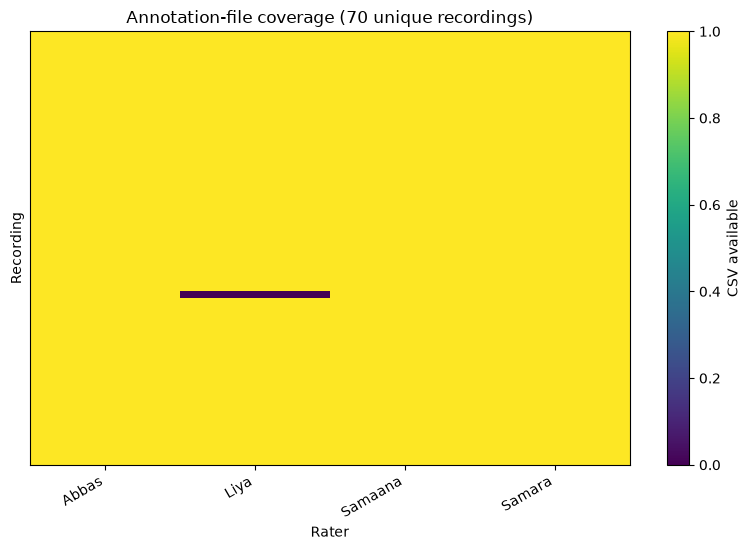

In [15]:
# Cell 13 — Figure: file coverage
fig, ax = plt.subplots(figsize=(8, max(4, len(coverage) * 0.08)))
image = ax.imshow(coverage[RATERS].to_numpy(), aspect="auto", interpolation="nearest", vmin=0, vmax=1)
ax.set_xticks(range(len(RATERS)), RATERS, rotation=30, ha="right")
ax.set_yticks([])
ax.set_title(f"Annotation-file coverage ({len(coverage)} unique recordings)")
ax.set_xlabel("Rater")
ax.set_ylabel("Recording")
fig.colorbar(image, ax=ax, label="CSV available")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_file_coverage.png", dpi=220, bbox_inches="tight")
plt.show()

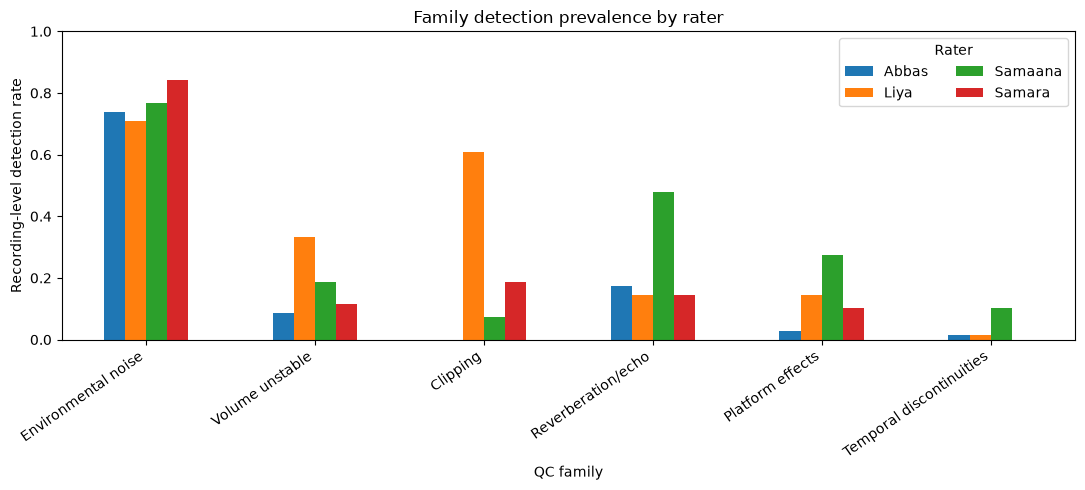

In [16]:
# Cell 14 — Figure: family detection rates by rater
family_rates = family_presence.groupby(["family", "rater"], as_index=False)["present"].mean()
pivot_rates = family_rates.pivot(index="family", columns="rater", values="present").reindex(ANALYSIS_FAMILIES)
ax = pivot_rates.plot(kind="bar", figsize=(11, 5))
ax.set_ylabel("Recording-level detection rate")
ax.set_xlabel("QC family")
ax.set_ylim(0, 1)
ax.set_title("Family detection prevalence by rater")
ax.legend(title="Rater", ncol=2)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_family_detection_rates.png", dpi=220, bbox_inches="tight")
plt.show()

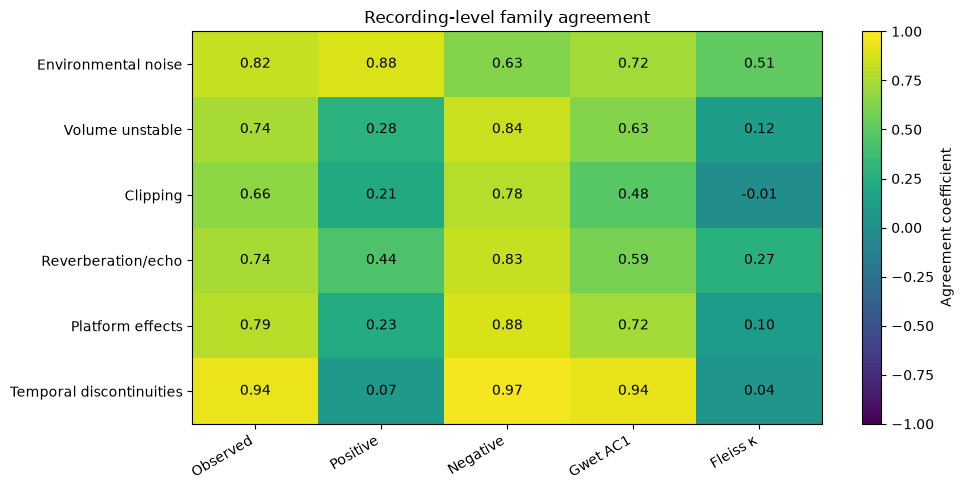

In [17]:
# Cell 15 — Figure: family reliability heatmap
heat = family_reliability.set_index("family")[[
    "observed_pairwise_agreement", "positive_agreement", "negative_agreement", "gwet_ac1", "fleiss_kappa"
]].reindex(ANALYSIS_FAMILIES)
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heat.to_numpy(), aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(heat.shape[1]), [
    "Observed", "Positive", "Negative", "Gwet AC1", "Fleiss κ"
], rotation=30, ha="right")
ax.set_yticks(range(heat.shape[0]), heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        value = heat.iloc[i, j]
        ax.text(j, i, "NA" if pd.isna(value) else f"{value:.2f}", ha="center", va="center")
ax.set_title("Recording-level family agreement")
fig.colorbar(im, ax=ax, label="Agreement coefficient")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_family_reliability_heatmap.png", dpi=220, bbox_inches="tight")
plt.show()

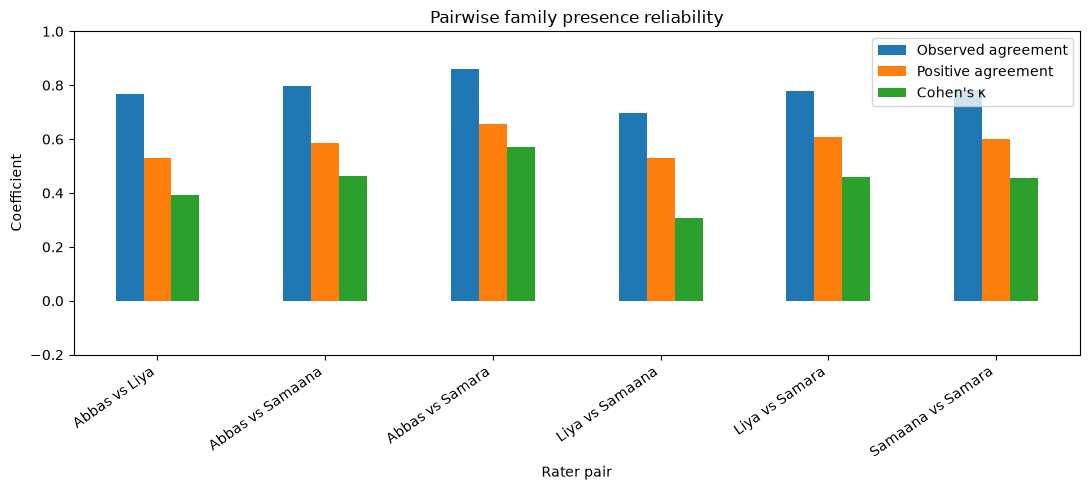

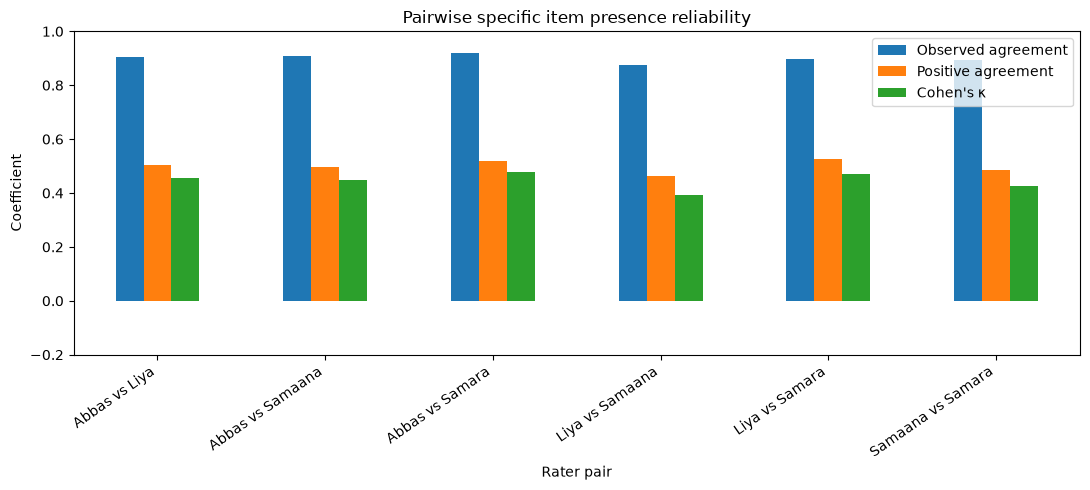

In [18]:
# Cell 16 — Figure: pairwise presence reliability
plot_df = pairwise_reliability.copy()
plot_df["pair"] = plot_df["rater_a"] + " vs " + plot_df["rater_b"]
for level in plot_df["analysis_level"].unique():
    sub = plot_df[plot_df["analysis_level"] == level].set_index("pair")[[
        "overall_agreement", "positive_agreement", "cohens_kappa"
    ]]
    ax = sub.plot(kind="bar", figsize=(11, 5))
    ax.set_ylim(-0.2, 1.0)
    ax.set_ylabel("Coefficient")
    ax.set_xlabel("Rater pair")
    ax.set_title(f"Pairwise {level} reliability")
    ax.legend(["Observed agreement", "Positive agreement", "Cohen's κ"])
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    safe_level = level.replace(" ", "_")
    plt.savefig(FIGURE_DIR / f"04_pairwise_{safe_level}.png", dpi=220, bbox_inches="tight")
    plt.show()

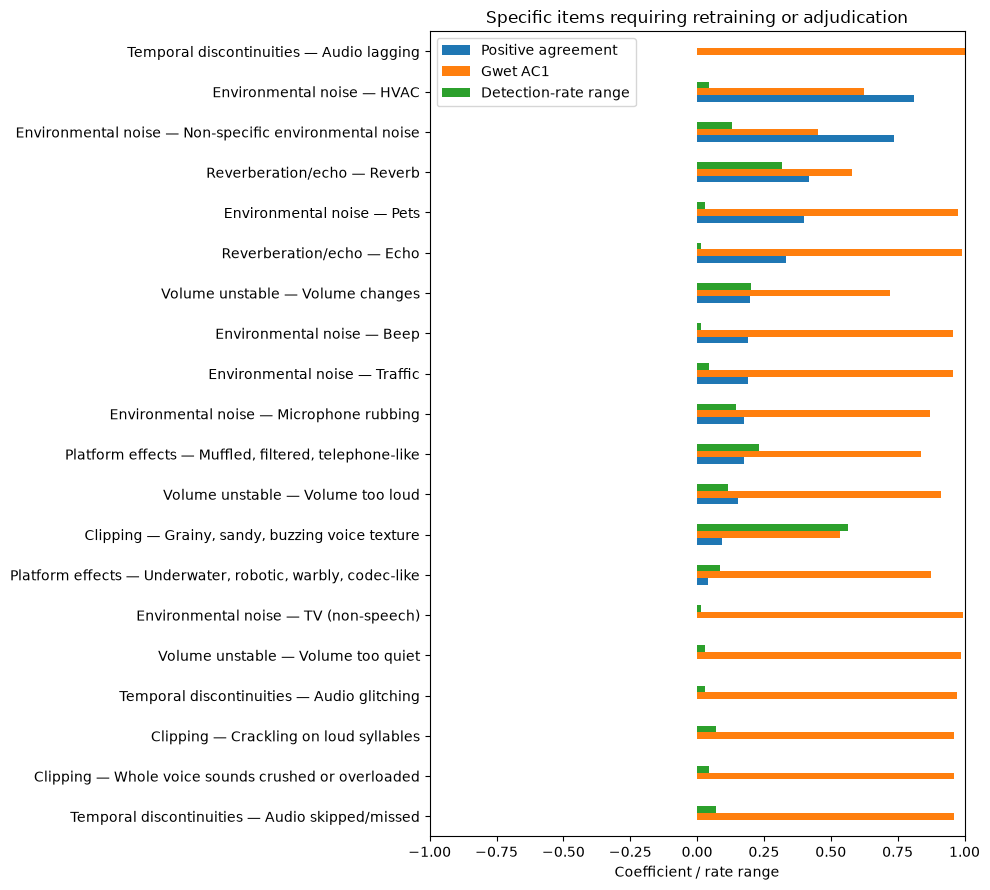

In [19]:
# Cell 17 — Figure: highest-priority item disagreements
top = disagreement_priority.head(20).copy()
top["label"] = top["family"] + " — " + top["item"]
plot = top.set_index("label")[["positive_agreement", "gwet_ac1", "detection_rate_range"]].sort_values("positive_agreement")
ax = plot.plot(kind="barh", figsize=(10, 9))
ax.set_xlim(-1, 1)
ax.set_xlabel("Coefficient / rate range")
ax.set_ylabel("")
ax.set_title("Specific items requiring retraining or adjudication")
ax.legend(["Positive agreement", "Gwet AC1", "Detection-rate range"])
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_item_disagreement_priorities.png", dpi=220, bbox_inches="tight")
plt.show()

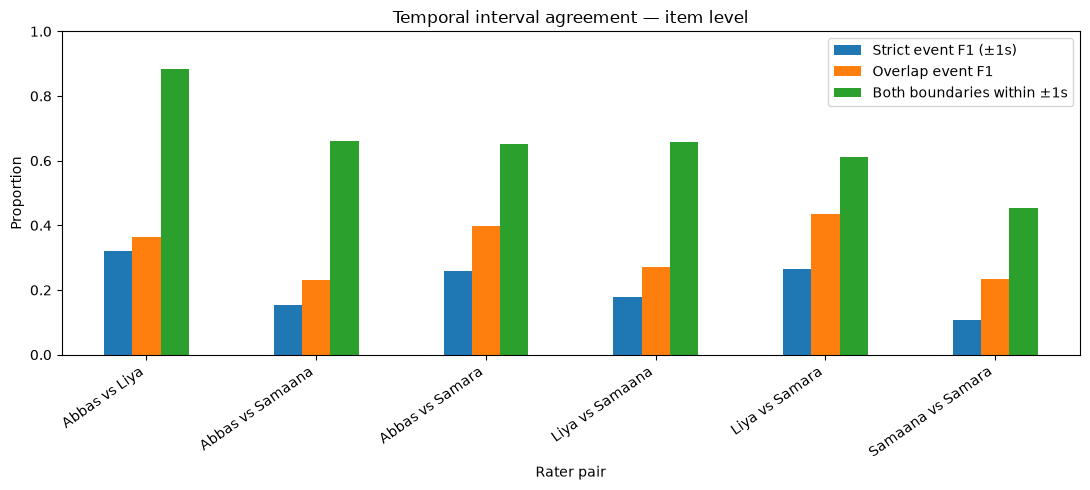

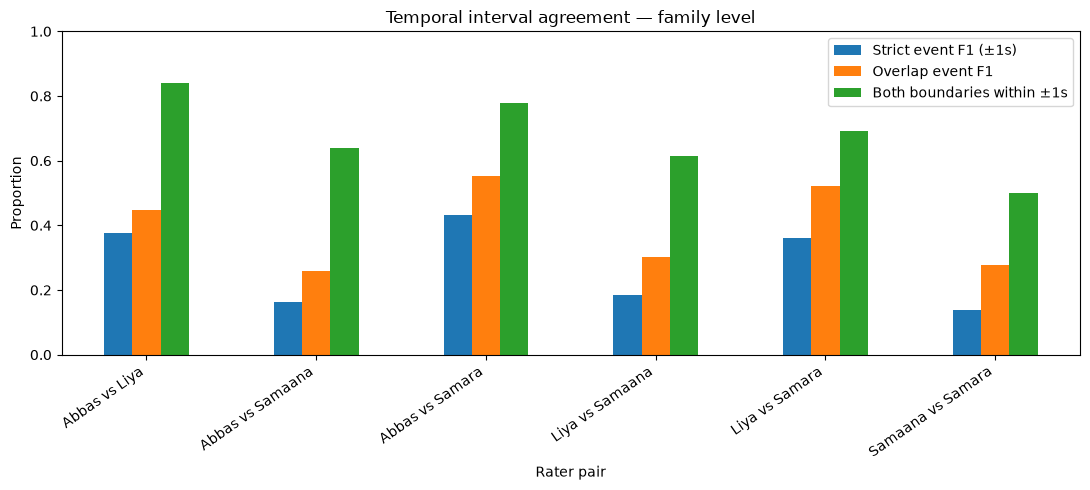

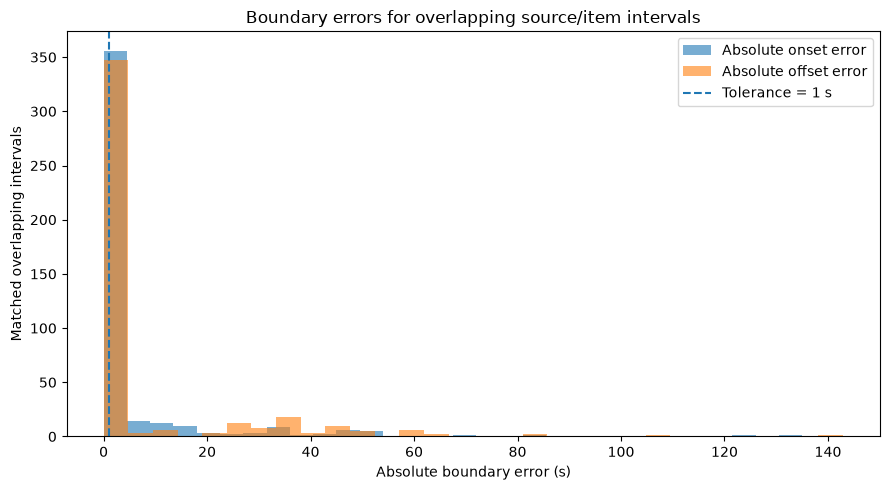

In [20]:
# Cell 18 — Figures: temporal agreement
for level in ["item", "family"]:
    sub = temporal_summary[temporal_summary["temporal_level"] == level].copy()
    if sub.empty:
        continue
    sub["pair"] = sub["rater_a"] + " vs " + sub["rater_b"]
    plot = sub.set_index("pair")[[
        "strict_event_f1", "overlap_event_f1", "overlap_matches_both_boundaries_within_tolerance"
    ]]
    ax = plot.plot(kind="bar", figsize=(11, 5))
    ax.set_ylim(0, 1)
    ax.set_ylabel("Proportion")
    ax.set_xlabel("Rater pair")
    ax.set_title(f"Temporal interval agreement — {level} level")
    ax.legend([f"Strict event F1 (±{TIME_TOLERANCE_SEC:g}s)", "Overlap event F1", f"Both boundaries within ±{TIME_TOLERANCE_SEC:g}s"])
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"06_temporal_{level}_summary.png", dpi=220, bbox_inches="tight")
    plt.show()

item_matches = temporal_matches[temporal_matches["temporal_level"] == "item"]
if not item_matches.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(item_matches["abs_onset_error_sec"].dropna(), bins=30, alpha=0.6, label="Absolute onset error")
    ax.hist(item_matches["abs_offset_error_sec"].dropna(), bins=30, alpha=0.6, label="Absolute offset error")
    ax.axvline(TIME_TOLERANCE_SEC, linestyle="--", label=f"Tolerance = {TIME_TOLERANCE_SEC:g} s")
    ax.set_xlabel("Absolute boundary error (s)")
    ax.set_ylabel("Matched overlapping intervals")
    ax.set_title("Boundary errors for overlapping source/item intervals")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "07_temporal_boundary_errors.png", dpi=220, bbox_inches="tight")
    plt.show()

## 6. Publication-ready numerical summary and manuscript text

The generated text is a reproducible draft tied directly to the exported results. Review it against the study's final terminology before placing it in the manuscript.

In [21]:
# Cell 19 — Generate manuscript-ready results and methods text

def pct(x):
    return "NA" if pd.isna(x) else f"{100*x:.1f}%"


def coef(x):
    return "NA" if pd.isna(x) else f"{x:.3f}"

family_overall = overall_reliability.loc[
    overall_reliability["analysis_level"] == "family presence"
].iloc[0]
item_overall = overall_reliability.loc[
    overall_reliability["analysis_level"] == "specific item presence"
].iloc[0]

item_temporal = temporal_summary[temporal_summary["temporal_level"] == "item"]
if not item_temporal.empty:
    pooled_events_a = int(item_temporal["events_a"].sum())
    pooled_events_b = int(item_temporal["events_b"].sum())
    pooled_strict_matches = int(item_temporal["strict_matches_within_tolerance"].sum())
    pooled_strict_f1 = safe_div(2 * pooled_strict_matches, pooled_events_a + pooled_events_b)
else:
    pooled_events_a = pooled_events_b = pooled_strict_matches = 0
    pooled_strict_f1 = np.nan

item_overlap_matches = temporal_matches[temporal_matches["temporal_level"] == "item"]
median_onset = item_overlap_matches["abs_onset_error_sec"].median() if not item_overlap_matches.empty else np.nan
median_offset = item_overlap_matches["abs_offset_error_sec"].median() if not item_overlap_matches.empty else np.nan
median_dice = item_overlap_matches["dice"].median() if not item_overlap_matches.empty else np.nan
boundary_pass = item_overlap_matches["both_boundaries_within_tolerance"].mean() if not item_overlap_matches.empty else np.nan

methods_text = (
    f"Inter-rater reliability was assessed across {len(COMMON_RECORDINGS)} recordings independently annotated by four trained raters. "
    "For family-level analyses, a family was coded as present when at least one constituent source was annotated anywhere in the recording. "
    "Specific-source agreement was calculated analogously for each item. Recording-level binary agreement was summarized using observed pairwise agreement, "
    "positive and negative agreement, Fleiss' kappa, and Gwet's AC1; Gwet's AC1 was treated as the primary chance-corrected coefficient because several labels were rare. "
    f"For temporal analyses, adjacent or overlapping intervals for the same source were first merged. Intervals were then matched one-to-one within each recording and source; "
    f"a temporal match required both onset and offset differences to be no greater than {TIME_TOLERANCE_SEC:g} s."
)

results_text = (
    f"Across {len(COMMON_RECORDINGS)} recordings rated by all four annotators, family-level presence agreement was "
    f"{pct(family_overall['observed_pairwise_agreement'])} (Gwet's AC1={coef(family_overall['gwet_ac1'])}; "
    f"Fleiss' κ={coef(family_overall['fleiss_kappa'])}; positive agreement={pct(family_overall['positive_agreement'])}; "
    f"negative agreement={pct(family_overall['negative_agreement'])}). "
    f"Agreement for specific source/item presence was {pct(item_overall['observed_pairwise_agreement'])} "
    f"(Gwet's AC1={coef(item_overall['gwet_ac1'])}; Fleiss' κ={coef(item_overall['fleiss_kappa'])}; "
    f"positive agreement={pct(item_overall['positive_agreement'])}; negative agreement={pct(item_overall['negative_agreement'])}). "
    f"Across all six rater pairs, the pooled item-level temporal event F1 within ±{TIME_TOLERANCE_SEC:g} s was {coef(pooled_strict_f1)} "
    f"({pooled_strict_matches} one-to-one matches; {pooled_events_a + pooled_events_b} total pairwise event annotations). "
    f"Among overlapping matched intervals, the median absolute onset and offset differences were {coef(median_onset)} s and {coef(median_offset)} s, respectively; "
    f"the median interval Dice coefficient was {coef(median_dice)}, and {pct(boundary_pass)} had both boundaries within the prespecified tolerance."
)

text = "METHODS\n\n" + methods_text + "\n\nRESULTS\n\n" + results_text + "\n"
(OUTPUT_DIR / "16_manuscript_text.txt").write_text(text, encoding="utf-8")
print(text)

METHODS

Inter-rater reliability was assessed across 69 recordings independently annotated by four trained raters. For family-level analyses, a family was coded as present when at least one constituent source was annotated anywhere in the recording. Specific-source agreement was calculated analogously for each item. Recording-level binary agreement was summarized using observed pairwise agreement, positive and negative agreement, Fleiss' kappa, and Gwet's AC1; Gwet's AC1 was treated as the primary chance-corrected coefficient because several labels were rare. For temporal analyses, adjacent or overlapping intervals for the same source were first merged. Intervals were then matched one-to-one within each recording and source; a temporal match required both onset and offset differences to be no greater than 1 s.

RESULTS

Across 69 recordings rated by all four annotators, family-level presence agreement was 78.1% (Gwet's AC1=0.643; Fleiss' κ=0.432; positive agreement=58.0%; negative agre

In [22]:
# Cell 20 — Save run manifest and final checks
manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "root": str(ROOT),
    "output_dir": str(OUTPUT_DIR),
    "raters": RATERS,
    "analysis_families": ANALYSIS_FAMILIES,
    "ancillary_families_excluded_from_primary": (
        [] if INCLUDE_ANCILLARY_IN_PRIMARY else ANCILLARY_FAMILIES
    ),
    "time_tolerance_sec": TIME_TOLERANCE_SEC,
    "merge_touching_gap_sec": MERGE_TOUCHING_GAP_SEC,
    "bootstrap_iterations": BOOTSTRAP_ITERATIONS,
    "random_seed": RANDOM_SEED,
    "csv_files": int(len(file_inventory)),
    "unique_recordings_any_rater": int(coverage.shape[0]),
    "common_recordings_all_four": int(len(COMMON_RECORDINGS)),
    "schema_items_primary": int(len(primary_schema)),
    "merged_events_primary": int(len(primary_item_events)),
}
(OUTPUT_DIR / "00_run_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

expected_outputs = [
    "00_run_manifest.json", "01_file_inventory.csv", "02_recording_coverage.csv",
    "03_annotation_schema.csv", "05_merged_event_ledger.csv", "06_family_presence_long.csv",
    "06_item_presence_long.csv", "07_overall_presence_reliability.csv",
    "08_family_reliability.csv", "09_item_reliability.csv",
    "10_pairwise_presence_reliability.csv", "12_temporal_unit_results.csv",
    "13_temporal_overlap_matches.csv", "14_temporal_pairwise_summary.csv",
    "15_disagreement_priority.csv", "16_manuscript_text.txt",
]
missing_outputs = [name for name in expected_outputs if not (OUTPUT_DIR / name).exists()]
if missing_outputs:
    raise RuntimeError(f"Expected outputs were not created: {missing_outputs}")

print("Analysis completed successfully.")
print(f"Results: {OUTPUT_DIR}")
print(f"Figures: {FIGURE_DIR}")

Analysis completed successfully.
Results: C:\Users\musikicn\Desktop\QC\Segmentation\Reliability\_reliability_analysis_outputs
Figures: C:\Users\musikicn\Desktop\QC\Segmentation\Reliability\_reliability_analysis_outputs\figures
